# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [30]:
%pip install gymnasium
%pip install "gymnasium[toy-text]"
%pip install minigrid

print("Décommentez les installations si nécessaire.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 3.5 MB/s eta 0:00:00
Décommentez les installations si nécessaire.


In [31]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [ ]:
# TODO
# Créer l'environnement Taxi-v3
# Afficher action_space, observation_space, spec et unwrapped

env = gym.make("Taxi-v3")

# Afficher les informations demandées
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Spec:", env.spec)
print("Unwrapped:", env.unwrapped)

Action space: Discrete(6)
Observation space: Discrete(500)
Spec: EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <TaxiEnv<Taxi-v3>>


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

## 2. Premier épisode avec actions aléatoires

In [ ]:
# TODO
# Exécuter un épisode aléatoire complet
# Afficher le nombre d'étapes, la récompense cumulée et la cause d'arrêt

env = gym.make("Taxi-v3")

obs, info = env.reset(seed=0)
episode_reward = 0.0
step_count = 0

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    step_count += 1

print("Nombre d'étapes :", step_count)
print("Récompense cumulée :", episode_reward)
print("Cause d'arrêt :", "terminated" if terminated else "truncated")

env.close()


Nombre d'étapes : 200
Récompense cumulée : -821.0
Cause d'arrêt : truncated


**Analyse :** que remarquez-vous sur les performances de cette politique ?

## 3. Politique aléatoire sur plusieurs épisodes

In [2]:
# TODO
# Écrire une fonction random_taxi_policy(obs, env)
# Lancer au moins 20 épisodes
# Stocker les résultats dans une liste ou un dictionnaire

def random_taxi_policy(obs, env):
    return env.action_space.sample()

env = gym.make("Taxi-v3")
results = []

for i in range(20):
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = random_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    results.append({
        "episode": i + 1,
        "total_reward": total_reward,
        "steps": steps,
        "success": terminated and reward == 20,
        "cause": "terminated" if terminated else "truncated"
    })

env.close()

for res in results:
    print(res)

{'episode': 1, 'total_reward': -521, 'steps': 146, 'success': True, 'cause': 'terminated'}
{'episode': 2, 'total_reward': -704, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 3, 'total_reward': -794, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 4, 'total_reward': -713, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 5, 'total_reward': -785, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 6, 'total_reward': -695, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 7, 'total_reward': -821, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 8, 'total_reward': -776, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 9, 'total_reward': -884, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 10, 'total_reward': -686, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 11, 'total_reward': -776, 'steps': 200, 'success': False, 'cause': 'truncated

In [6]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès

total_rewards = []
total_steps = []
successes = []

for res in results:
    total_rewards.append(res["total_reward"])
    total_steps.append(res["steps"])
    successes.append(res["success"])

somme_rewards = sum(total_rewards)
nombre_episodes = len(total_rewards)
avg_reward = somme_rewards / nombre_episodes

somme_steps = sum(total_steps)
avg_steps = somme_steps / nombre_episodes

somme_succes = 0
for s in successes:
    if s == True:
        somme_succes = somme_succes + 1

success_rate = (somme_succes / nombre_episodes) * 100

print(avg_reward)
print(avg_steps)
print(success_rate, "pourcent")

-732.05
192.35
10.0 pourcent


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [8]:
# TODO
# Implémenter une politique aléatoire contrainte

import gymnasium as gym
import numpy as np

def constrained_random_taxi_policy(obs, env):
    list_obs = list(env.unwrapped.decode(obs))
    taxi_row = list_obs[0]
    taxi_col = list_obs[1]
    pass_idx = list_obs[2]
    dest_idx = list_obs[3]

    locations = [(0, 0), (0, 4), (4, 0), (4, 3)]
    taxi_loc = (taxi_row, taxi_col)

    actions_possibles = [0, 1, 2, 3]

    if pass_idx < 4:
        if taxi_loc == locations[pass_idx]:
            actions_possibles.append(4)

    if pass_idx == 4:
        if taxi_loc == locations[dest_idx]:
            actions_possibles.append(5)

    return np.random.choice(actions_possibles)

env = gym.make("Taxi-v3")
results_constrained = []

for i in range(20):
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = constrained_random_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    if terminated:
        if reward == 20:
            success = True
        else:
            success = False
    else:
        success = False

    if terminated:
        cause = "terminated"
    else:
        cause = "truncated"

    results_constrained.append({
        "episode": i + 1,
        "total_reward": total_reward,
        "steps": steps,
        "success": success,
        "cause": cause
    })

env.close()

In [12]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte

total_rewards_simple = []
total_steps_simple = []
successes_simple = []

for res in results:
    total_rewards_simple.append(res["total_reward"])
    total_steps_simple.append(res["steps"])
    successes_simple.append(res["success"])

nombre_episodes_s = len(total_rewards_simple)
avg_reward_s = sum(total_rewards_simple) / nombre_episodes_s
avg_steps_s = sum(total_steps_simple) / nombre_episodes_s
rate_s = (sum(successes_simple) / nombre_episodes_s) * 100

total_rewards_const = []
total_steps_const = []
successes_const = []

for res in results_constrained:
    total_rewards_const.append(res["total_reward"])
    total_steps_const.append(res["steps"])
    successes_const.append(res["success"])

nombre_episodes_c = len(total_rewards_const)
avg_reward_c = sum(total_rewards_const) / nombre_episodes_c
avg_steps_c = sum(total_steps_const) / nombre_episodes_c
rate_c = (sum(successes_const) / nombre_episodes_c) * 100

print(f"aleatoire : {avg_reward_s} // contrainte : {avg_reward_c}")
print(f"aleatoire: {avg_steps_s} // contrainte : {avg_steps_c}")
print(f"aleatoire : {rate_s}% // contrainte: {rate_c}% .")

aleatoire : -732.05 // contrainte : -184.2
aleatoire: 192.35 // contrainte : 186.3
aleatoire : 10.0% // contrainte: 10.0% .


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

## 5. Politique heuristique simple pour Taxi-v3

In [21]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire

env = gym.make("Taxi-v3")
obs, info = env.reset()

parametres = list(env.unwrapped.decode(obs))
ligne = parametres[0]
colonne = parametres[1]
passager = parametres[2]
destination = parametres[3]

print(f"L'état {obs} correspond au taxi en ligne {ligne} et colonne {colonne}, avec le passager à l'index {passager} et la destination à l'index {destination}.")

env.close()

L'état 24 correspond au taxi en ligne 0 et colonne 1, avec le passager à l'index 1 et la destination à l'index 0.


In [ ]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)

def heuristic_taxi_policy(obs, env):
    list_obs = list(env.unwrapped.decode(obs))
    taxi_row = list_obs[0]
    taxi_col = list_obs[1]
    pass_idx = list_obs[2]
    dest_idx = list_obs[3]

    locations = [(0, 0), (0, 4), (4, 0), (4, 3)]

    if pass_idx < 4:
        target_row = locations[pass_idx][0]
        target_col = locations[pass_idx][1]
    else:
        target_row = locations[dest_idx][0]
        target_col = locations[dest_idx][1]

    if pass_idx < 4 and taxi_row == target_row and taxi_col == target_col:
        return 4

    if pass_idx == 4 and taxi_row == target_row and taxi_col == target_col:
        return 5

    if taxi_row < target_row:
        return 0
    if taxi_row > target_row:
        return 1
    if taxi_col < target_col:
        return 2
    if taxi_col > target_col:
        return 3

    return 0

In [22]:
# TODO
# Évaluer cette politique sur plusieurs épisodes

env = gym.make("Taxi-v3")
results_heuristic = []

for i in range(20):
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = heuristic_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    if terminated:
        if reward == 20:
            success = True
        else:
            success = False
    else:
        success = False

    if terminated:
        cause = "terminated"
    else:
        cause = "truncated"

    results_heuristic.append({
        "episode": i + 1,
        "total_reward": total_reward,
        "steps": steps,
        "success": success,
        "cause": cause
    })

env.close()

for res in results_heuristic:
    print(res)

{'episode': 1, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 2, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 3, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 4, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 5, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 6, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 7, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 8, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 9, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 10, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated'}
{'episode': 11, 'total_reward': -200, 'steps': 200, 'success': False, 'cause': 'truncated

**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?

## 6. Tableau comparatif pour Taxi-v3

In [23]:
# TODO
# Construire un tableau comparant les trois politiques Taxi

total_rewards_h = []
total_steps_h = []
successes_h = []

for res in results_heuristic:
    total_rewards_h.append(res["total_reward"])
    total_steps_h.append(res["steps"])
    successes_h.append(res["success"])

nombre_episodes_h = len(total_rewards_h)
avg_reward_h = sum(total_rewards_h) / nombre_episodes_h
avg_steps_h = sum(total_steps_h) / nombre_episodes_h
rate_h = (sum(successes_h) / nombre_episodes_h) * 100

print(f"{'Indicateur':<20} | {'Aléatoire':<12} | {'Contrainte':<12} | {'Heuristique':<12}")
print("-" * 65)
print(f"{'Récompense moy.':<20} | {avg_reward_s:<12.1f} | {avg_reward_c:<12.1f} | {avg_reward_h:<12.1f}")
print(f"{'Étapes moy.':<20} | {avg_steps_s:<12.1f} | {avg_steps_c:<12.1f} | {avg_steps_h:<12.1f}")
print(f"{'Succès (%)':<20} | {rate_s:<12.1f} | {rate_c:<12.1f} | {rate_h:<12.1f}")

Indicateur           | Aléatoire    | Contrainte   | Heuristique 
-----------------------------------------------------------------
Récompense moy.      | -732.0       | -184.2       | -189.2      
Étapes moy.          | 192.3        | 186.3        | 190.3       
Succès (%)           | 10.0         | 10.0         | 5.0         


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [36]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec

import gymnasium as gym
import minigrid

env = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env.reset()

print("Espace d'action :", env.action_space)
print("Type d'observation :", type(obs))
print("Clés disponibles :", obs.keys() if isinstance(obs, dict) else "N/A")

env.close()

Espace d'action : Discrete(7)
Type d'observation : <class 'dict'>
Clés disponibles : dict_keys(['image', 'direction', 'mission'])


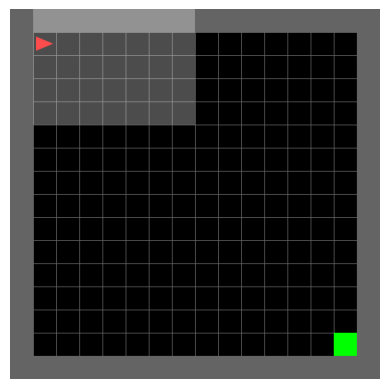

In [34]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib

import gymnasium as gym
import minigrid
import matplotlib.pyplot as plt

env = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env.reset()

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.show()

env.close()

**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?

## 8. Politique aléatoire sur MiniGrid

In [44]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes

import gymnasium as gym
import minigrid
import numpy as np

def random_minigrid_policy(obs, env):
    return env.action_space.sample()

env = gym.make("MiniGrid-Empty-16x16-v0")
results_minigrid_random = []

for i in range(20):
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = random_minigrid_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    results_minigrid_random.append({
        "episode": i + 1,
        "total_reward": total_reward,
        "steps": steps,
        "success": terminated and reward > 0,
        "cause": "terminated" if terminated else "truncated"
    })

env.close()

total_rewards_al = []
total_steps_al = []
successes_al = []

for res in results_minigrid_random:
    total_rewards_al.append(res["total_reward"])
    total_steps_al.append(res["steps"])
    successes_al.append(res["success"])

nombre_episodes = len(results_minigrid_random)
avg_reward_al = sum(total_rewards_al) / nombre_episodes
avg_steps_al = sum(total_steps_al) / nombre_episodes
success_rate_al = (sum(successes_al) / nombre_episodes) * 100

print(avg_reward_al)
print(avg_steps_al)
print(success_rate_al)

0.05208984374999999
981.8
15.0


## 9. Politique réflexe minimale sur MiniGrid

In [41]:
# TODO
# Implémenter une politique à règles locales simples

import gymnasium as gym
import minigrid

def reflex_minigrid_policy(obs):
    image = obs['image']
    objet_devant = image[3, 5, 0]

    if objet_devant == 1 or objet_devant == 8:
        return 2
    else:
        return 1

In [48]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
import gymnasium as gym

env = gym.make("MiniGrid-Empty-16x16-v0")
results_reflex = []

for i in range(20):
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = reflex_minigrid_policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    results_reflex.append({
        "episode": i + 1,
        "total_reward": total_reward,
        "steps": steps,
        "success": terminated and reward > 0
    })

env.close()

total_rewards = []
total_steps = []
successes = []

for res in results_reflex:
    total_rewards.append(res["total_reward"])
    total_steps.append(res["steps"])
    successes.append(res["success"])

nombre_episodes = len(results_reflex)
avg_reward = sum(total_rewards) / nombre_episodes
avg_steps = sum(total_steps) / nombre_episodes
rate = (sum(successes) / nombre_episodes) * 100

print(f"al : {avg_reward_al} // ref min {avg_reward} ")
print(f"al : {avg_steps_al} // ref min {avg_steps} ")
print(f"al : {success_rate_al} // ref min {rate} ")

al : 0.05208984374999999 // ref min 0.97626953125 
al : 981.8 // ref min 27.0 
al : 15.0 // ref min 100.0 


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?

## 10. Politique d’exploration avec mémoire minimale

In [51]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
import gymnasium as gym
import minigrid
import numpy as np

class MemoryPolicy:
    def __init__(self):
        self.history = []

    def __call__(self, obs):
        image = obs['image']
        objet_devant = image[3, 5, 0]

        if objet_devant == 8:
            action = 2
        elif objet_devant == 1:
            action = 2
        else:
            if len(self.history) > 0 and self.history[-1] == 0:
                action = 0
            else:
                action = 1

        self.history.append(action)
        return action

In [58]:
# TODO
# Évaluer cette politique et comparer les résultats
env = gym.make("MiniGrid-Empty-16x16-v0")
policy = MemoryPolicy()
results_memory = []

for i in range(20):
    obs, info = env.reset()
    policy.history = []
    total_reward = 0
    steps = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    results_memory.append({
        "total_reward": total_reward,
        "steps": steps,
        "success": terminated and reward > 0
    })

env.close()

rewards_mem = [res["total_reward"] for res in results_memory]
steps_mem = [res["steps"] for res in results_memory]
successes_mem = [res["success"] for res in results_memory]

avg_reward_mem = sum(rewards_mem) / len(rewards_mem)
avg_steps_mem = sum(steps_mem) / len(steps_mem)
rate_mem = (sum(successes_mem) / len(successes_mem)) * 100

print(avg_reward_mem)
print(avg_steps_mem)
print(rate_mem)

0.97626953125
27.0
100.0


## 11. Wrapper utile : RecordEpisodeStatistics

In [57]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]
import gymnasium as gym
import minigrid

env = gym.make("MiniGrid-Empty-16x16-v0")
env = RecordEpisodeStatistics(env)

obs, info = env.reset()
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

if "episode" in info:
    print(f"Récompense totale : {info['episode']['r']}")
    print(f"Longueur totale : {info['episode']['l']}")
    print(f"Temps écoulé : {info['episode']['t']}")

env.close()

Récompense totale : 0.2529296875
Longueur totale : 850
Temps écoulé : 0.119407


## 12. Comparaison finale

In [62]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées

print(f"{'Aléatoire':<12} | {'ref min':<12} | {'memoire min':<12}")
print("-" * 65)
print(f"{'Récompense moy.':<20} | {avg_reward_al:<12.1f} | {avg_reward_c:<12.1f} | {avg_reward_mem:<12.1f}")
print(f"{'Étapes moy.':<20} | {avg_steps_al:<12.1f} | {avg_steps_c:<12.1f} | {avg_steps_mem:<12.1f}")
print(f"{'Succès (%)':<20} | {success_rate_al:<12.1f} | {rate:<12.1f} | {rate_mem:<12.1f}")


Aléatoire    | ref min      | memoire min 
-----------------------------------------------------------------
Récompense moy.      | 0.1          | -184.2       | 1.0         
Étapes moy.          | 981.8        | 186.3        | 27.0        
Succès (%)           | 15.0         | 100.0        | 100.0       


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?

le plus facile est surement l'environnement du taxi du fait que le wrapper d'information est plus facile a controler et qu'il suffit qu'il ne rentre pas dans un obstacle

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?

L'environnement de la grille du fait qu'il est plus difficile a maitriser et qu'il faut aussi avoir une mémoire pour ne pas boucler sur les memes cases

3. Quelles sont les limites principales des politiques codées à la main ?

on peut totalement oublier ou mal maitriser un élement de l'environnement, surtout si c'est un environnement très énormissime

4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?

puisque les politiques codées à la main sont problématiques, rien ne peut les remplacer si ce n'est l'apprentissage par renforcement pour automatiser ce processus

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [63]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    frames = []

    obs, info = env.reset(seed=seed)

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, env)

        obs, reward, terminated, truncated, info = env.step(action)

        steps = steps + 1

    env.close()

    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [64]:
import matplotlib.pyplot as plt

def show_selected_frames(frames):
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames) // 2, len(frames) - 1]

    for idx in indices:
        plt.figure(figsize=(4, 4))

        image = frames[idx]
        plt.imshow(image)

        plt.axis("off")

        plt.title(f"Frame {idx}")

        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [65]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

In [73]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

TypeError: generic_random_policy() missing 2 required positional arguments: 'env' and 'step_idx'

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [71]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")

    env = RecordVideo(
        env,
        video_folder=str(video_folder),
        name_prefix=episode_name,
        episode_trigger=lambda x: True
    )

    obs, info = env.reset(seed=seed)

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, env)

        obs, reward, terminated, truncated, info = env.step(action)

        steps = steps + 1

    env.close()

    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [72]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


TypeError: generic_random_policy() missing 2 required positional arguments: 'env' and 'step_idx'

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [70]:
# TODO
# Produire ici 2 ou 3 vidéos pour comparer les politiques sur Taxi ou MiniGrid.

record_policy_video(
    env_id="Taxi-v3",
    policy_fn=random_taxi_policy,
    video_folder="videos/taxi_random",
    episode_name="taxi_random")
record_policy_video(
    env_id="Taxi-v3",
    policy_fn=heuristic_taxi_policy,
    video_folder="videos/taxi_heuristic",
    episode_name="taxi_heuristic")
record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=policy,
    video_folder="videos/minigrid_memory",
    episode_name="minigrid_memory")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/taxi_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/taxi_heuristic folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/minigrid_memory folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desi

TypeError: MemoryPolicy.__call__() takes 2 positional arguments but 3 were given

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?

Non on ne voit aucun comportement cohérent, du moins pour le taxi, du fait qu'il tourne autour de lui sans cesse

2. Quelle politique semble la plus efficace à l'observation ?

la politique heuristique semble plus efficace

3. Voyez-vous des hésitations, répétitions ou blocages ?

oui on peut remarquer des répetitions et des blocages sur les heuristiques aléatoires, et de moins en moins vers les politiques dirigées

4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?

en effet on peut un peu comprendre les métriques numériques données

5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?

celle du minigrid du fait que la grille est grande et donc l'agent peut se perdre beaucoup plus facilement et on peut le voir faire des tours bizarres et revenir aux memes places ou il était


### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.
